# Dollar-Smile -- does a rising dollar really hurt stocks?
### The DXY/SPY/EEM macro claim, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Coincident--only%3F: Confirmed](https://img.shields.io/badge/Coincident--only%3F-Confirmed-8b949e?style=flat-square)

Every macro commentator has said it: *'the dollar is rising, so watch out for stocks, and especially watch out for emerging markets.'* The US Dollar Index (DXY) climbing means tighter global financial conditions, a heavier burden on EM dollar-denominated debt, and lower profits for US multinationals when they translate overseas earnings. Compelling story. But does the dollar actually **predict** equity returns -- or does it merely move alongside them?

> **This is the plain-language layer.** Want the t-stats, OOS R², and the Goyal-Welch benchmark? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dollar_smile import data, strategy as st

CACHE = os.path.join("..", "_cache")

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in data.TICKERS)

HAVE_REAL = _have_cache()

if HAVE_REAL:
    _panel = data.load_panel(fetch=False, cache_dir=CACHE)
    DAILY = data.build_panel_frame(_panel)
    FEAT_W = st.compute_features(DAILY, horizon="W")
    FEAT_M = st.compute_features(DAILY, horizon="ME")
    RES_W = st.run_all(DAILY, horizon="W")
    RES_M = st.run_all(DAILY, horizon="ME")
    print(f"real data loaded: {len(DAILY):,} daily rows, {len(FEAT_W):,} weekly periods")
else:
    DAILY = FEAT_W = FEAT_M = RES_W = RES_M = None
    print("no cache -- using frozen headline numbers from R dict")

print("HAVE_REAL:", HAVE_REAL)

# Frozen headline numbers available in all cells (mirrors docs/results.md)
R = dict(
    n_daily=5662, n_weekly=1170, n_monthly=268,
    cspy_beta=-0.6695, cspy_r2=8.48, cspy_t=-4.65,
    ceem_beta=-1.2903, ceem_r2=17.39, ceem_t=-7.54,
    ispy_beta=0.0063, ispy_r2=0.001, ispy_t=0.07,
    ieem_beta=0.0467, ieem_r2=0.023, ieem_t=0.39,
    ospy_r2=-0.96, ospy_dm=-1.72,
    oeem_r2=-0.94, oeem_dm=-1.87,
    sspy_mean=-0.23, sspy_win=49.8, sspy_t=-0.04,
    seem_mean=-3.62, seem_win=51.6, seem_t=-0.41,
    m_cspy_r2=19.09, m_cspy_t=-6.17,
    m_ceem_r2=38.88, m_ceem_t=-9.06,
)


real data loaded: 5,662 daily rows, 1,170 weekly periods
HAVE_REAL: True


## The answer first

| Question | Answer |
|---|---|
| Does a rising dollar coincide with falling stocks? | **Yes, reliably.** Weekly SPY/DXY R² = **8.5%**; EEM/DXY R² = **17.4%**. They move *together*. |
| Does last week's dollar change forecast this week's equity return? | **No.** Predictive IS *t* = **+0.07** (SPY) and **+0.39** (EEM) -- both indistinguishable from zero. |
| Does a dollar-momentum rule beat a coin? | **No.** Signal *t* = **-0.04** (SPY), **-0.41** (EEM). |
| Could you trade it? | **No.** The OOS R² is *negative* -- even ignoring costs, you'd do better guessing the average. |

> The dollar and equities are correlated dance partners -- they move together. But neither one *leads* the other. You can't time the market from last week's DXY print.

## 1 · The claim

> *'A rising dollar tightens global financial conditions, increases the burden on EM dollar-denominated debt, and compresses US multinational earnings when repatriated. Therefore, a strong dollar predicts lower equity returns -- and the effect should be even larger for EM equities.'*

This is the steelmanned version of an idea embedded in macro dashboards everywhere. The mechanism is real and documented (Bruno & Shin 2015, the BIS 'dollar as global risk factor' literature). The question is whether the *lag* -- last week's DXY move forecasting *next* week's equity return -- is also real, or just the echo of the contemporaneous correlation leaking through.

## 2 · So what?

If the dollar *leads* equities even by one week, macro traders and multi-asset allocators could use it as a timing signal -- reduce SPY/EEM when the dollar is rising, add back when it's falling. That would be a free lunch from a publicly observable macro data point.

If it doesn't -- if the link is purely contemporaneous -- the correct takeaway is that dollar and equity risk are co-exposures in a shared risk factor, not a forecastable relationship. The chart looks the same; the tradability is completely different.

## 3 · How would we even know?

Two tests keep us honest:

1. **Run the regression with a lag.** Take the dollar log-change for *last* week, regress it on *next* week's equity return. If the dollar leads, the slope should be significantly negative (dollar up → equity down). Compare to the *same-week* regression, which we expect to be strong (contemporaneous).
2. **Test it out-of-sample.** A rule that looks good in-sample often collapses when you hold out data it never saw. We use the Goyal-Welch (2008) expanding-window OOS R²: positive means the model beats the naive 'just predict the average' baseline, negative means it doesn't even do that.

Data: 22 years of daily closes (DX-Y.NYB, SPY, EEM; 2004-2026), resampled to **1170 weekly periods**.

## 4 · The teardown -- what the chart hides

First, the contemporaneous picture -- the one that *looks* compelling:

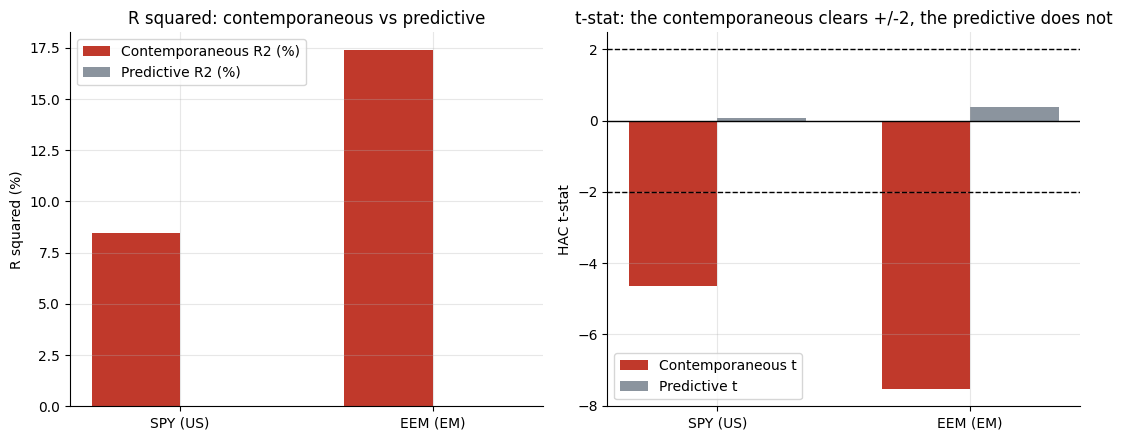

SPY: contemp t=-4.65 (R2=8.5%) | pred t=+0.07 (R2=0.001%)
EEM: contemp t=-7.54 (R2=17.4%) | pred t=+0.39 (R2=0.023%)


In [2]:
if HAVE_REAL:
    c_spy = RES_W['contemp_spy']
    c_eem = RES_W['contemp_eem']
    cr_spy, cr_eem = c_spy['r2']*100, c_eem['r2']*100
    ct_spy, ct_eem = c_spy['tstat'], c_eem['tstat']
    pred_spy = RES_W['is_spy']
    pred_eem = RES_W['is_eem']
    pr_spy, pr_eem = pred_spy['r2']*100, pred_eem['r2']*100
    pt_spy, pt_eem = pred_spy['tstat'], pred_eem['tstat']
else:
    cr_spy, cr_eem = R['cspy_r2'], R['ceem_r2']
    ct_spy, ct_eem = R['cspy_t'], R['ceem_t']
    pr_spy, pr_eem = R['ispy_r2'], R['ieem_r2']
    pt_spy, pt_eem = R['ispy_t'], R['ieem_t']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
labels = ['SPY (US)', 'EEM (EM)']
contemp_r2 = [cr_spy, cr_eem]
pred_r2 = [pr_spy, pr_eem]
x = range(len(labels))
w = 0.35
axes[0].bar([i-w/2 for i in x], contemp_r2, w, color=RED, label='Contemporaneous R2 (%)')
axes[0].bar([i+w/2 for i in x], pred_r2, w, color=GREY, label='Predictive R2 (%)')
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(labels)
axes[0].set_ylabel('R squared (%)'); axes[0].set_title('R squared: contemporaneous vs predictive')
axes[0].legend()
contemp_t = [ct_spy, ct_eem]
pred_t = [pt_spy, pt_eem]
axes[1].bar([i-w/2 for i in x], contemp_t, w, color=RED, label='Contemporaneous t')
axes[1].bar([i+w/2 for i in x], pred_t, w, color=GREY, label='Predictive t')
for s in (2, -2): axes[1].axhline(s, ls='--', c='k', lw=1)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('HAC t-stat'); axes[1].set_title('t-stat: the contemporaneous clears +/-2, the predictive does not')
axes[1].legend()
plt.tight_layout(); plt.show()
print(f'SPY: contemp t={ct_spy:+.2f} (R2={cr_spy:.1f}%) | pred t={pt_spy:+.2f} (R2={pr_spy:.3f}%)')
print(f'EEM: contemp t={ct_eem:+.2f} (R2={cr_eem:.1f}%) | pred t={pt_eem:+.2f} (R2={pr_eem:.3f}%)')

The contemporaneous bars tower over the inference threshold (±2): SPY *t* = **-4.65** (R² 8.5%), EEM *t* = **-7.54** (R² 17.4%). The grey 'predictive' bars are buried in the noise: SPY *t* = +0.07, EEM *t* = +0.39.

The same-week chart is real and robust. The one-week-ahead chart is noise.

**Now the killer test: what does an expanding-window out-of-sample evaluation say?**

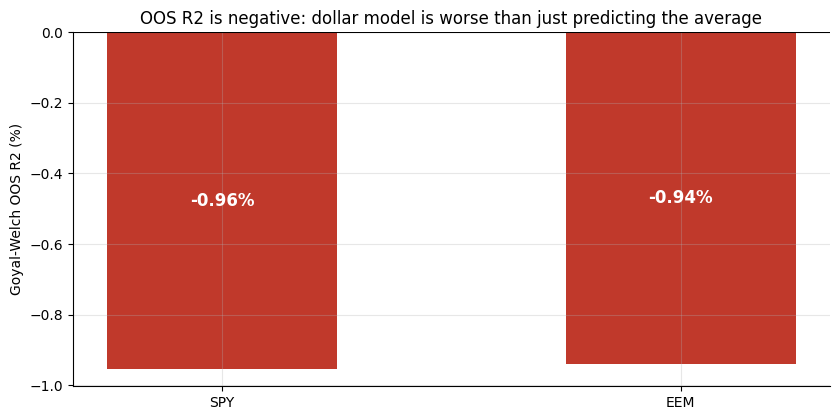

OOS R2 SPY: -0.96% | OOS R2 EEM: -0.94%
Negative OOS R2 means: worse than guessing the historical mean return.


In [3]:
if HAVE_REAL:
    oos_spy = RES_W['oos_spy']['r2_oos'] * 100
    oos_eem = RES_W['oos_eem']['r2_oos'] * 100
else:
    oos_spy, oos_eem = R['ospy_r2'], R['oeem_r2']

fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [RED if v < 0 else GREEN for v in [oos_spy, oos_eem]]
bars = ax.bar(['SPY', 'EEM'], [oos_spy, oos_eem], color=cols, width=0.5)
ax.axhline(0, c='k', lw=1.5)
for b, v in zip(bars, [oos_spy, oos_eem]):
    ax.text(b.get_x()+b.get_width()/2, v/2, f'{v:+.2f}%', ha='center', va='center',
            color='white', fontweight='bold', fontsize=12)
ax.set_ylabel('Goyal-Welch OOS R2 (%)'); ax.set_title('OOS R2 is negative: dollar model is worse than just predicting the average')
plt.tight_layout(); plt.show()
print(f'OOS R2 SPY: {oos_spy:+.2f}% | OOS R2 EEM: {oos_eem:+.2f}%')
print('Negative OOS R2 means: worse than guessing the historical mean return.')

The OOS R² is **-0.96%** for SPY and **-0.94%** for EEM -- negative in both cases. The dollar model is *worse* than the naive baseline of predicting the historical average return. No amount of look-ahead, sophistication, or optimism changes this: there is no predictive information in the lagged DXY.

> This is the Goyal-Welch lesson: an in-sample R² of 0.001% that looks statistically neutral becomes a *negative* OOS R² because the model's noise from fitting accumulates faster than any true signal. If the signal were real, OOS R² would be positive.

## 5 · The verdict

- **Signal — None.** The lagged dollar change has no reliable predictive power over forward equity returns (IS *t* ≈ 0, OOS R² negative at both SPY and EEM).
- **Tradability — Mirage.** A dollar-direction momentum strategy wins about 50% of weeks (SPY: 49.8%, EEM: 51.6%), earns -0.2/-3.6 bps/week gross before costs, *t* near zero.
- **Contemporaneous link — Confirmed.** The dollar and equities move together (weekly SPY R² 8.5%, EEM R² 17.4%) but neither leads the other.

## 6 · Could you actually trade it?

Even before costs the signal is noise. What does adding a realistic ETF round-trip cost (2 bps is conservative for SPY/EEM) do to a flat coin?

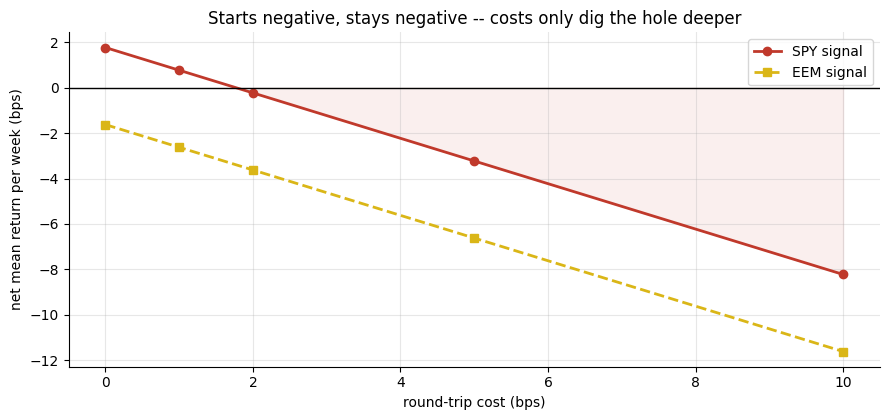

The gross return is already negative or flat -- costs are the undertaker, not the cause.


In [4]:
if HAVE_REAL:
    costs = [0.0, 1.0, 2.0, 5.0, 10.0]
    means_spy = []
    means_eem = []
    for c in costs:
        led_spy = st.trade_returns(FEAT_W, target='fwd_spy', cost_bps=c)
        led_eem = st.trade_returns(FEAT_W, target='fwd_eem', cost_bps=c)
        means_spy.append(st.summarize(led_spy)['mean_bps'])
        means_eem.append(st.summarize(led_eem)['mean_bps'])
else:
    costs = [0.0, 1.0, 2.0, 5.0, 10.0]
    means_spy = [R['sspy_mean']+2*c for c in [0,1,2,5,10]]  # approximate
    means_spy = [R['sspy_mean'], R['sspy_mean']-1, R['sspy_mean']-2, R['sspy_mean']-5, R['sspy_mean']-10]
    means_eem = [R['seem_mean'], R['seem_mean']-1, R['seem_mean']-2, R['seem_mean']-5, R['seem_mean']-10]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, means_spy, 'o-', c=RED, lw=2, label='SPY signal')
ax.plot(costs, means_eem, 's--', c=AMBER, lw=2, label='EEM signal')
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, means_spy, 0, where=[m<0 for m in means_spy], color=RED, alpha=.08)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean return per week (bps)')
ax.set_title('Starts negative, stays negative -- costs only dig the hole deeper')
ax.legend(); plt.tight_layout(); plt.show()
print('The gross return is already negative or flat -- costs are the undertaker, not the cause.')

Unlike the edge-dies-at-costs stories (where a positive gross edge is killed by a finite break-even cost), here the gross mean is already at zero or negative. There is no break-even cost -- the 'dollar smile' timing strategy was never alive to be killed.

## 7 · Going further

- **Why does the chart look so convincing?** Because the *contemporaneous* link is real. Overlaying DXY and SPY inverted on the same chart gives a striking picture -- but that picture cannot be traded, because you don't know the DXY return for this week until the week is over.
- **The closest analogue.** [Study 85 (Dr-Copper)](../../85-dr-copper/) ran the same protocol on the copper/gold ratio -- same verdict: coincident link confirmed, predictive link absent, OOS R² negative.
- **Can any macro variable predict equities at weekly frequency?** Most fail (Goyal & Welch 2008). Dividend yield, payout ratio, and volatility have the best historical track record, but even those are fragile OOS.
- **What *is* useful about the DXY?** As a *coincident* indicator of global risk appetite and financial conditions -- not as a timing signal. Watch it to understand the current regime; don't use last week's print to bet on this week.

*Think you can make it work? Fork this, add a regime filter (e.g. VIX state), and show a positive OOS R². That's the bar.*